In [1]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
data = load_iris()
X = data.data
y = data.target


In [3]:

# Step 1: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:

# Step 2: Apply KMeans without PCA
kmeans_no_pca = KMeans(n_clusters=3, random_state=42)
labels_no_pca = kmeans_no_pca.fit_predict(X_scaled)
score_no_pca = silhouette_score(X_scaled, labels_no_pca)



C:\Users\Satyam\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Satyam\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Satyam\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Satyam\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Satyam\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

In [5]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [6]:

# Step 4: Apply KMeans on PCA-reduced data
kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)
score_pca = silhouette_score(X_pca, labels_pca)


C:\Users\Satyam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Text(0, 0.5, 'Feature 2')

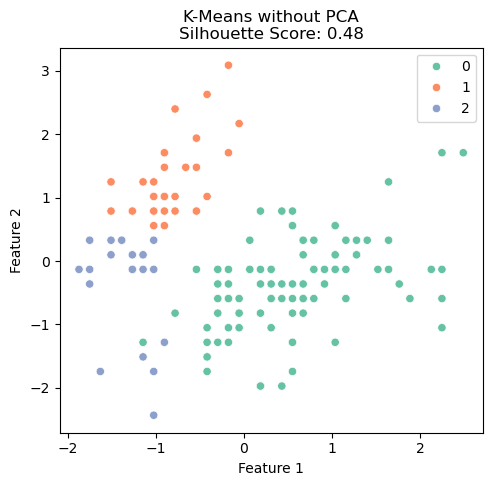

In [7]:

# Step 5: Plotting both results
plt.figure(figsize=(12, 5))

# Without PCA
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels_no_pca, palette="Set2")
plt.title(f"K-Means without PCA\nSilhouette Score: {score_no_pca:.2f}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

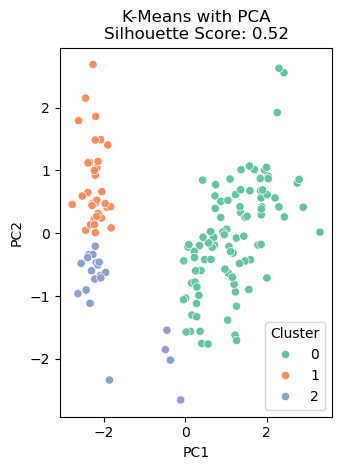

In [8]:
# With PCA
plt.subplot(1, 2, 2)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = labels_pca
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster", palette="Set2")
plt.title(f"K-Means with PCA\nSilhouette Score: {score_pca:.2f}")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()